# まずは疑似的なGCMC

8.31446261815324
P = 0.001 bar | Coverage = 0.524
P = 0.002 bar | Coverage = 0.620
P = 0.004 bar | Coverage = 0.718
P = 0.007 bar | Coverage = 0.811
P = 0.014 bar | Coverage = 0.879
P = 0.027 bar | Coverage = 0.929
P = 0.052 bar | Coverage = 0.960
P = 0.100 bar | Coverage = 0.979
P = 0.193 bar | Coverage = 0.988
P = 0.373 bar | Coverage = 0.994
P = 0.720 bar | Coverage = 0.997
P = 1.389 bar | Coverage = 0.998
P = 2.683 bar | Coverage = 0.999
P = 5.179 bar | Coverage = 1.000
P = 10.000 bar | Coverage = 1.000


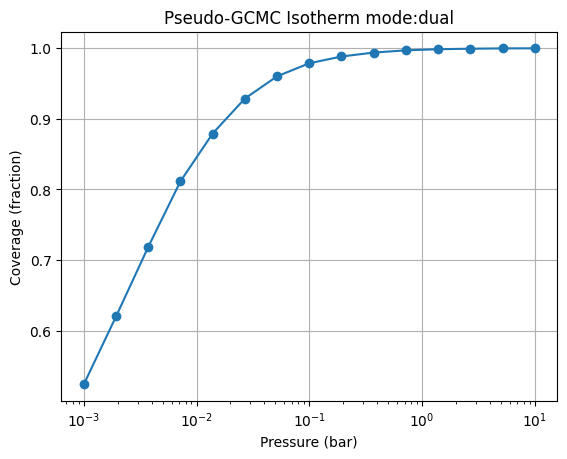

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 物理定数
# ==============================
kB = 1.380649e-23          # J/K　      ボルツマン定数
NA = 6.02214076e23         # 1/mol      アボガドロ定数
R  = kB * NA               # J/mol/K    モル気体定数
print(R)

# ==============================
# シミュレーション設定
# ==============================
T = 298.0                  # 温度 (K)
beta = 1.0 / (R * T)       # 逆温度に対応(本来は1/(kB*T)なのだが、モル当たりの量の方が計算に便利) 

N_sites = 2000             # 吸着サイト数
n_steps = 200000           # MCステップ数
equil_steps = 50000        # 平衡化ステップ

# ==============================
# 吸着エネルギー分布を定義
# ==============================

def generate_energy_distribution(mode="dual"):
    """
    吸着エネルギーεの分布を生成
    エネルギー単位: J/mol（負値 = 安定）
    ⇒ 

    """
    if mode == "single":
        eps = np.full(N_sites, -20000.0)  # -20 kJ/mol
    elif mode == "dual":
        # random.normal(mu, sigma, data_size)
        strong = np.random.normal(-30000.0, 2000.0, int(N_sites*0.3))
        weak   = np.random.normal(-15000.0, 2000.0, int(N_sites*0.7))
        eps = np.concatenate([strong, weak])
        
    elif mode == "broad":
        eps = np.random.normal(-22000.0, 7000.0, N_sites)
    else:
        raise ValueError("Unknown mode")
    return eps

# ==============================
# μと圧力の関係（理想気体近似）
# ==============================

def chemical_potential(P, P0=1.0):
    """
    P: 圧力 (bar)
    P0: 基準圧 (bar)
    戻り値: μ (J/mol)

    理想気体の化学ポテンシャル
    μ = μ^0(T) + kT*ln(P/P0)
    → μ^0は定数扱いでOK（相対比較目的なら）
    """
    mu = R * T * np.log(P / P0)

    return mu

# ==============================
# GCMCコア
# ==============================

def run_gcmc(eps, mu):
    """
    eps: 吸着エネルギー配列 (J/mol)
    mu : 化学ポテンシャル (J/mol)
    """
    occupancy = np.zeros(N_sites, dtype=int)
    N_ads = 0

    ads_history = []

    # metropolis method
    for step in range(n_steps):
        i = np.random.randint(0, N_sites)

        if occupancy[i] == 0:
            # 挿入試行
            deltaE = eps[i]
            prob = np.exp(-beta * (deltaE - mu))
            if np.random.rand() < min(1.0, prob):
                occupancy[i] = 1
                N_ads += 1
        else:
            # 削除試行
            deltaE = -eps[i]
            prob = np.exp(-beta * (deltaE + mu))
            if np.random.rand() < min(1.0, prob):
                occupancy[i] = 0
                N_ads -= 1

        if step > equil_steps:
            ads_history.append(N_ads)

    return np.mean(ads_history)

# ==============================
# 等温線計算
# ==============================

def compute_isotherm(eps, pressures):
    adsorption = []
    for P in pressures:
        mu = chemical_potential(P)
        avg_ads = run_gcmc(eps, mu)
        adsorption.append(avg_ads / N_sites)  # 被覆率
        print(f"P = {P:.3f} bar | Coverage = {adsorption[-1]:.3f}")
    return np.array(adsorption)

# ==============================
# 実行部
# ==============================

if __name__ == "__main__":

    pressures = np.logspace(-3, 1, 15)  # 0.001〜10 bar

    mode = "dual"

    eps = generate_energy_distribution(mode=mode)

    coverage = compute_isotherm(eps, pressures)

    # ==============================
    # プロット
    # ==============================

    plt.figure()
    plt.semilogx(pressures, coverage, marker='o')
    plt.xlabel("Pressure (bar)")
    plt.ylabel("Coverage (fraction)")
    plt.title(f"Pseudo-GCMC Isotherm mode:{mode}")
    plt.grid(True)
    plt.show()


In [1]:
print(R)

NameError: name 'R' is not defined

P = 0.001 bar | Coverage = 0.761
P = 0.002 bar | Coverage = 0.861
P = 0.004 bar | Coverage = 0.922
P = 0.007 bar | Coverage = 0.958
P = 0.014 bar | Coverage = 0.978
P = 0.027 bar | Coverage = 0.989
P = 0.052 bar | Coverage = 0.994
P = 0.100 bar | Coverage = 0.997
P = 0.193 bar | Coverage = 0.998
P = 0.373 bar | Coverage = 0.999
P = 0.720 bar | Coverage = 1.000
P = 1.389 bar | Coverage = 1.000
P = 2.683 bar | Coverage = 1.000
P = 5.179 bar | Coverage = 1.000
P = 10.000 bar | Coverage = 1.000


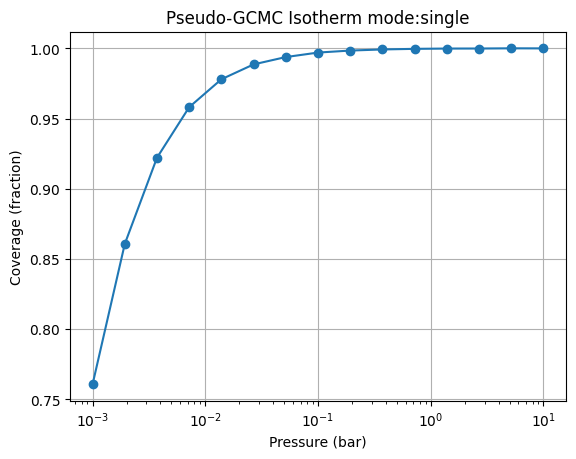

In [3]:
if __name__ == "__main__":

    pressures = np.logspace(-3, 1, 15)  # 0.001〜10 bar

    mode = "single"

    eps = generate_energy_distribution(mode=mode)

    coverage = compute_isotherm(eps, pressures)

    # ==============================
    # プロット
    # ==============================

    plt.figure()
    plt.semilogx(pressures, coverage, marker='o')
    plt.xlabel("Pressure (bar)")
    plt.ylabel("Coverage (fraction)")
    plt.title(f"Pseudo-GCMC Isotherm mode:{mode}")
    plt.grid(True)
    plt.show()
